In [89]:
!pip install tensorflow 

In [90]:
import tensorflow as tf

In [91]:
from keras.datasets import mnist

In [92]:
import matplotlib.pyplot as plt
import numpy as np

In [93]:
(X_train,y_train),(X_test,y_test) = tf.keras.datasets.mnist.load_data()

In [94]:
X_train = X_train[:100]
y_train = y_train[:100]
y_test=y_test[:10]
X_test=X_test[:10]

In [95]:
print('The shape of the training inputs:', X_train.shape)
print('The shape of the training labels:',y_train.shape)
print('The shape of the testing inputs:',X_test.shape)
print('The shape of the testing labels:',y_test.shape)

The shape of the training inputs: (100, 28, 28)
The shape of the training labels: (100,)
The shape of the testing inputs: (10, 28, 28)
The shape of the testing labels: (10,)


In [96]:
X_train = X_train.reshape(100, 28*28) / 127.5 - 1

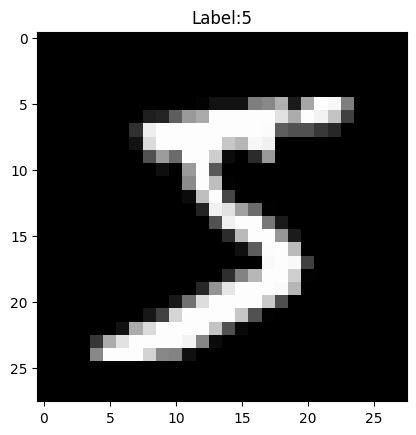

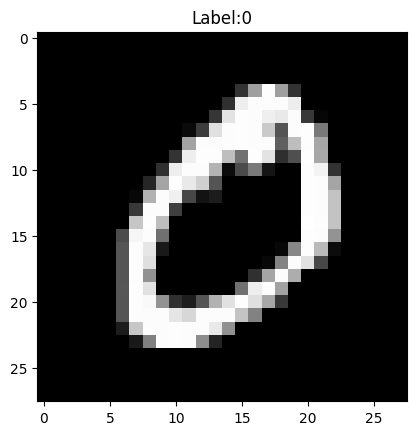

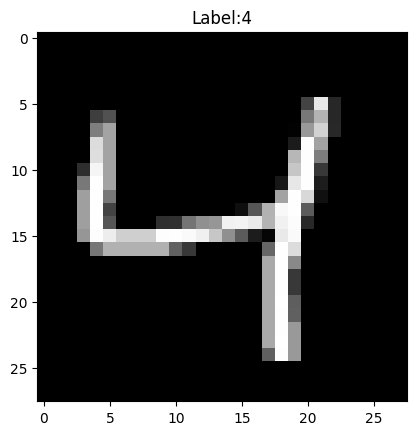

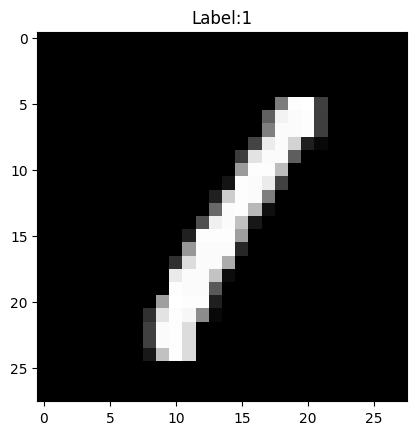

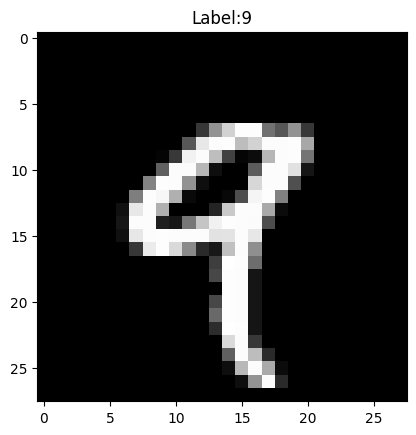

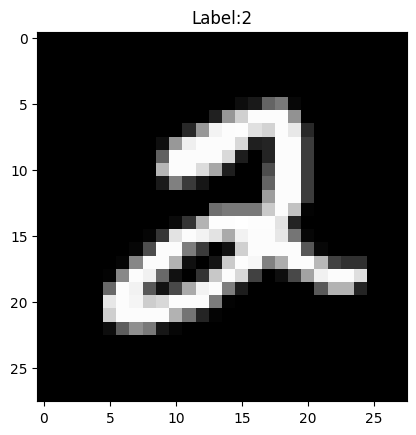

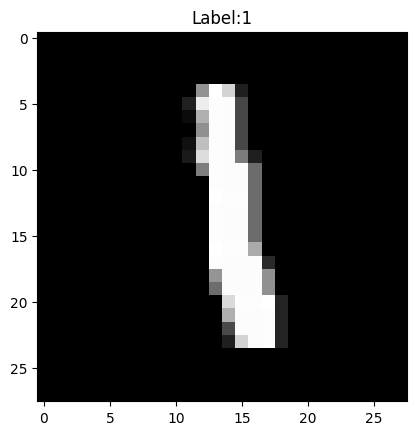

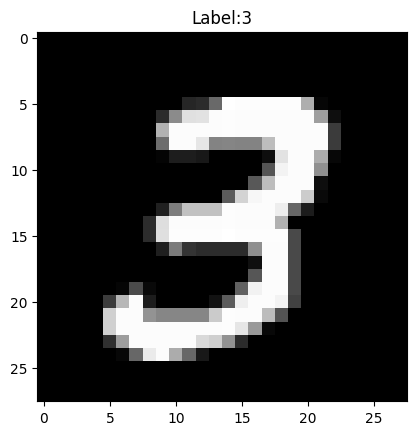

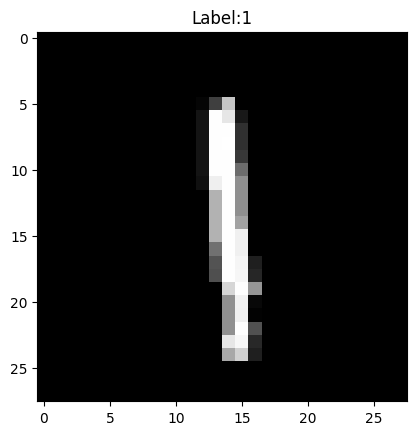

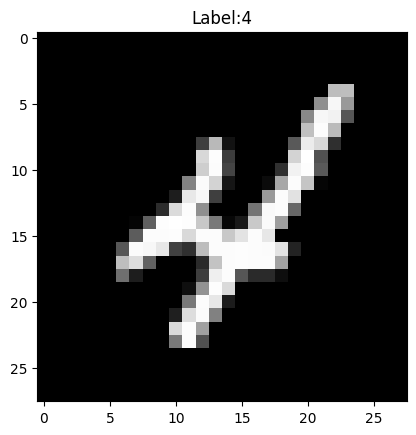

In [97]:
for img,label in zip(X_train[:10],y_train[:10]):
    plt.imshow(img.reshape(28,28),cmap="gray")
    plt.title(f"Label:{label}")
    plt.show()

In [98]:
# Convert labels to bipolar encoding (-1 for non-target, 1 for target)
def to_bipolar(y, num_classes=10):
    bipolar = -np.ones((len(y), num_classes))
    for i, label in enumerate(y):
        bipolar[i, label] = 1
    return bipolar

y_train_bipolar = to_bipolar(y_train)

In [99]:
y_train_bipolar

array([[-1., -1., -1., -1., -1.,  1., -1., -1., -1., -1.],
       [ 1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
       [-1., -1., -1., -1.,  1., -1., -1., -1., -1., -1.],
       [-1.,  1., -1., -1., -1., -1., -1., -1., -1., -1.],
       [-1., -1., -1., -1., -1., -1., -1., -1., -1.,  1.],
       [-1., -1.,  1., -1., -1., -1., -1., -1., -1., -1.],
       [-1.,  1., -1., -1., -1., -1., -1., -1., -1., -1.],
       [-1., -1., -1.,  1., -1., -1., -1., -1., -1., -1.],
       [-1.,  1., -1., -1., -1., -1., -1., -1., -1., -1.],
       [-1., -1., -1., -1.,  1., -1., -1., -1., -1., -1.],
       [-1., -1., -1.,  1., -1., -1., -1., -1., -1., -1.],
       [-1., -1., -1., -1., -1.,  1., -1., -1., -1., -1.],
       [-1., -1., -1.,  1., -1., -1., -1., -1., -1., -1.],
       [-1., -1., -1., -1., -1., -1.,  1., -1., -1., -1.],
       [-1.,  1., -1., -1., -1., -1., -1., -1., -1., -1.],
       [-1., -1., -1., -1., -1., -1., -1.,  1., -1., -1.],
       [-1., -1.,  1., -1., -1., -1., -1., -1., -1., -1.

In [100]:
def bipolar_sigmoid(x):
    return 2 / (1 + np.exp(-x)) - 1

def bipolar_sigmoid_derivative(y):
    # Note: y is already phi(x)
    return 0.5 * (1 + y) * (1 - y)

In [101]:
input_size = 784 #input layer
hidden_size = 64  # hidden layer
output_size = 10 # output layer
learning_rate = 0.1
epochs = 100

In [102]:
# Initialize weights and biases
np.random.seed(42)
W1 = np.random.uniform(-0.5, 0.5, (input_size, hidden_size))
b1 = np.zeros(hidden_size)
W2 = np.random.uniform(-0.5, 0.5, (hidden_size, output_size))
b2 = np.zeros(output_size)

In [103]:
for epoch in range(epochs):
    total_loss = 0
    total_error = 0 
    correct = 0 
    total = 0 
    i=0
    for x, t in zip(X_train, y_train_bipolar): 
        # Forward pass 
        h_input = np.dot(x, W1) + b1 
        h_output = bipolar_sigmoid(h_input) 
        y_input = np.dot(h_output, W2) + b2 
        y_output = bipolar_sigmoid(y_input) 
        
        # Error calculation 
        error = t - y_output 
        total_error += np.sum(error**2) / 2 
        loss = np.mean(error ** 2)
        total_loss += loss
        
        # Prediction 
        y_pred = np.argmax(y_output) # predicted class 
        y_true = np.argmax(t) # true class 
        
        if y_pred == y_true: 
            correct += 1 
        total += 1 
            
        # Backpropagation 
        delta_output = error * bipolar_sigmoid_derivative(y_output) 
        delta_hidden = bipolar_sigmoid_derivative(h_output) * np.dot(W2, delta_output) 
            
        # Weight updates 
        w2_update = learning_rate * np.outer(h_output, delta_output)
        W2 += w2_update
        b2 += learning_rate * delta_output 

        w1_update = learning_rate * np.outer(x, delta_hidden)
        W1 += w1_update
        b1 += learning_rate * delta_hidden 

        # Detailed print only for epoch 5 and only for first 5 samples
        if epoch == epochs - 1 and i < 5:
            print(f"\nSample {i+1} \nForward Pass:")
            print(f"Calculate hidden layer weighted sums z1 = input_vector . W1")
            print(f"First 5 weighted sums: {np.round(h_input[:5], 5)}")

            print(f"Apply bipolar sigmoid activation to z1:")
            print(f"Hidden activations a1 (first 5): {np.round(h_output[:5], 5)}")

            print(f"\nCalculate output layer weighted sums z2 = a1 . W2")
            print(f"Output weighted sums z2 (first 5): {np.round(h_input[:5], 5)}")

            print(f"Apply bipolar sigmoid activation to z2:")
            print(f"Output activations a2 (first 5): {np.round(h_output[:5], 5)}")

            print(f"\nError Calculation:")
            print(f"Calculate error = target Y - output a2:")
            print(f"Error (first 5): {np.round(error[:5], 5)}")
            print(f"Mean squared error loss for sample: {loss:.7f}")

            print(f"\nBackpropagation:")
            print(f"Delta output layer (delta2) = error * derivative of bipolar sigmoid at a2")
            print(f"delta2 (first 5): {np.round(delta_output[:5], 7)}")

            print(f"Delta hidden layer (delta1) = (delta2 . W2.T) * derivative of bipolar sigmoid at a1")
            print(f"delta1 (first 5): {np.round(delta_hidden[:5], 7)}")

            print(f"\nWeight Updates:")
            print(f"W2 update = learning_rate * outer product of (a1, delta2)")
            print(f"W2 update (first row, first 5): {np.round(w2_update[0,:5], 8)}")

            print(f"W1 update = learning_rate * outer product of (input vector, delta1)")
            print(f"W1 update (first 5 input pixels, first hidden neuron): {np.round(w1_update[:5,0], 8)}")
            i += 1

    avg_loss = total_loss / len(X_train)
    accuracy = correct / len(X_train) * 100
    print(f"\nEpoch {epoch+1} Summary: Average Loss = {avg_loss:.5f}, Accuracy = {accuracy:.2f}%")
    

    accuracy = correct / total * 100 
    print(f"Epoch {epoch+1}/{epochs}, Error: {total_error:.4f}, Accuracy: {accuracy:.2f}%")


Epoch 1 Summary: Average Loss = 0.37950, Accuracy = 19.00%
Epoch 1/100, Error: 189.7499, Accuracy: 19.00%

Epoch 2 Summary: Average Loss = 0.32245, Accuracy = 36.00%
Epoch 2/100, Error: 161.2249, Accuracy: 36.00%

Epoch 3 Summary: Average Loss = 0.29273, Accuracy = 45.00%
Epoch 3/100, Error: 146.3656, Accuracy: 45.00%

Epoch 4 Summary: Average Loss = 0.25096, Accuracy = 55.00%
Epoch 4/100, Error: 125.4811, Accuracy: 55.00%

Epoch 5 Summary: Average Loss = 0.23384, Accuracy = 61.00%
Epoch 5/100, Error: 116.9181, Accuracy: 61.00%

Epoch 6 Summary: Average Loss = 0.20490, Accuracy = 67.00%
Epoch 6/100, Error: 102.4494, Accuracy: 67.00%

Epoch 7 Summary: Average Loss = 0.18337, Accuracy = 71.00%
Epoch 7/100, Error: 91.6856, Accuracy: 71.00%

Epoch 8 Summary: Average Loss = 0.12670, Accuracy = 79.00%
Epoch 8/100, Error: 63.3515, Accuracy: 79.00%

Epoch 9 Summary: Average Loss = 0.12647, Accuracy = 79.00%
Epoch 9/100, Error: 63.2325, Accuracy: 79.00%

Epoch 10 Summary: Average Loss = 0.1412

Predicted: 7, True: 7


/var/folders/dw/c2_50bb909sgck_k5bp92j_r0000gn/T/ipykernel_73436/2271848517.py:2: RuntimeWarning: overflow encountered in exp
  return 2 / (1 + np.exp(-x)) - 1


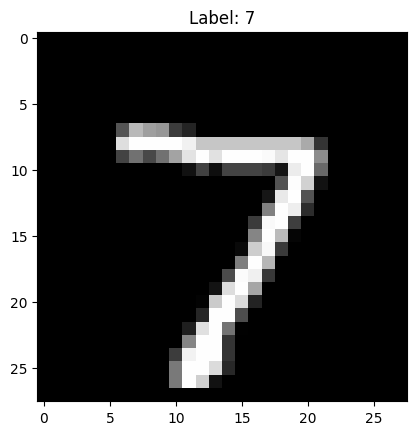

Predicted: 0, True: 2


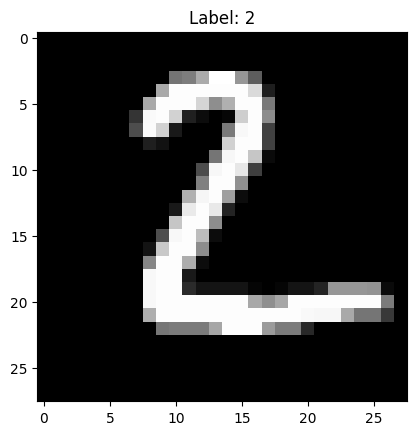

Predicted: 1, True: 1


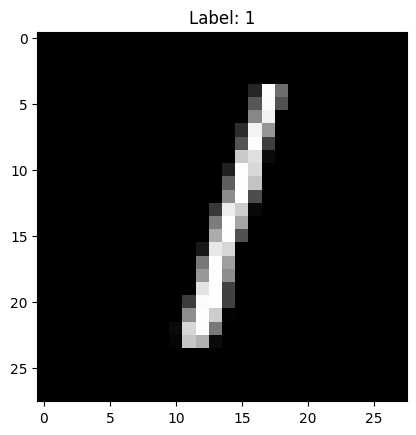

Predicted: 0, True: 0


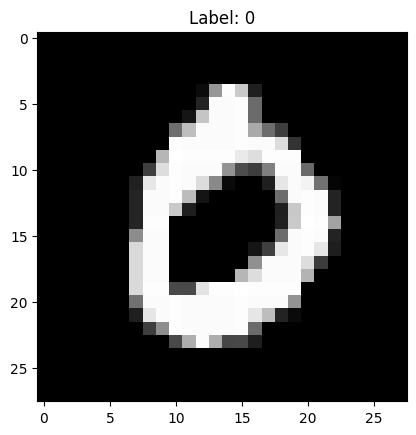

Predicted: 4, True: 4


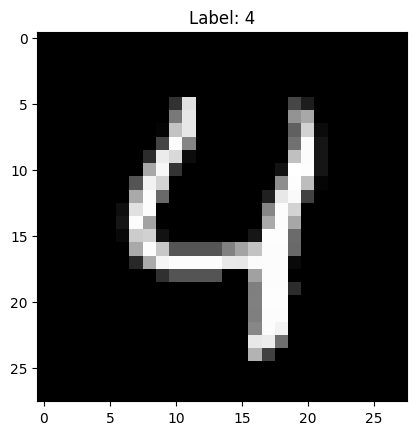

Predicted: 1, True: 1


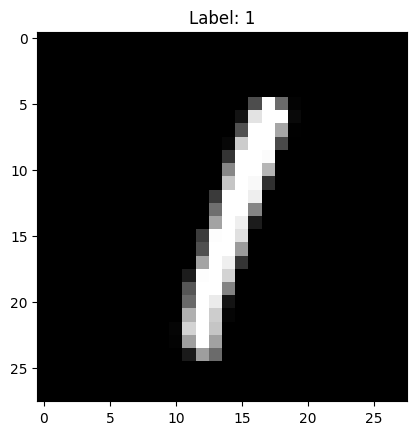

Predicted: 9, True: 4


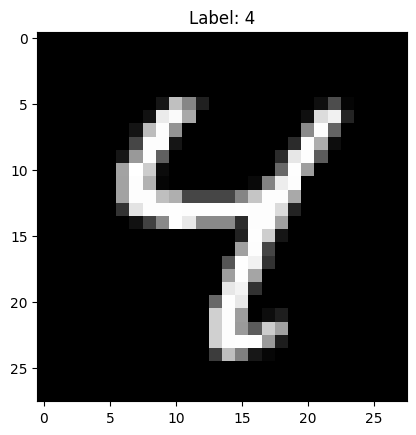

Predicted: 9, True: 9


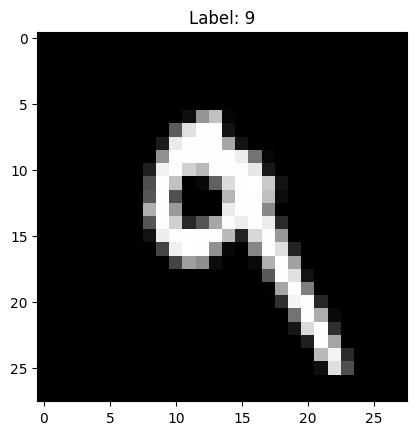

Predicted: 8, True: 5


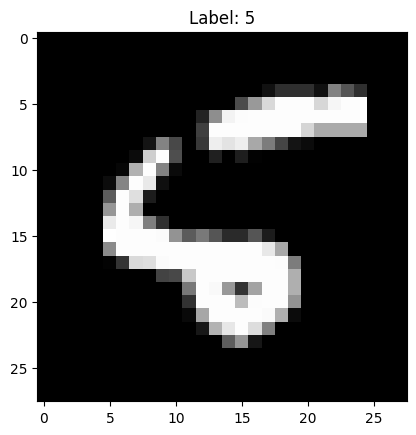

Predicted: 9, True: 9


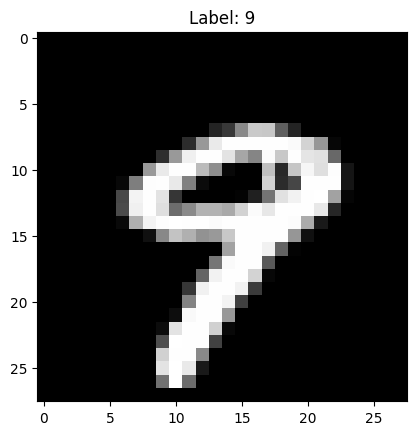

In [104]:
for img, label in zip(X_test, y_test):

    # Flatten image for NN input
    x = img.reshape(1, -1)

    plt.imshow(img.reshape(28, 28), cmap="gray")

    # Forward pass
    h_input = np.dot(x, W1) + b1
    h_output = bipolar_sigmoid(h_input)

    y_input = np.dot(h_output, W2) + b2
    y_output = bipolar_sigmoid(y_input)

    # Predictions
    y_pred = np.argmax(y_output)
    y_true = label   

    print(f"Predicted: {y_pred}, True: {y_true}")

    plt.title(f"Label: {label}")
    plt.show()
